In [3]:
# ==========================================================
# Credit Approval Flag Classification
# Pipeline Version
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb

import joblib

RANDOM_STATE = 42

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
from google.colab import files

uploaded = files.upload()

Saving case_study2.xlsx to case_study2.xlsx
Saving case_study1.xlsx to case_study1.xlsx


In [5]:
a1 = pd.read_excel("case_study1.xlsx")
a2 = pd.read_excel("case_study2.xlsx")

df1 = a1.copy()
df2 = a2.copy()

print(df1.shape)
print(df2.shape)

(51336, 26)
(51336, 62)


In [6]:
# Remove nulls

df1 = df1.loc[df1["Age_Oldest_TL"] != -99999]

columns_to_be_removed = []

for col in df2.columns:

    if (df2[col] == -99999).sum() > 10000:

        columns_to_be_removed.append(col)

df2.drop(columns=columns_to_be_removed, inplace=True)

for col in df2.columns:

    df2 = df2.loc[df2[col] != -99999]

print(df1.shape)
print(df2.shape)

(51296, 26)
(42066, 54)


In [7]:
df = pd.merge(
    df1,
    df2,
    how="inner",
    on="PROSPECTID"
)

print(df.shape)

(42064, 79)


In [8]:
#categorical columns
TARGET = "Approved_Flag"

ID = "PROSPECTID"

categorical_columns = [

    col

    for col in df.columns

    if df[col].dtype == "object"

    and col != TARGET

]

print(categorical_columns)

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


In [9]:
#chi square
selected_categorical = []

print("Chi Square Results\n")

for col in categorical_columns:

    chi2, p, _, _ = chi2_contingency(

        pd.crosstab(df[col], df[TARGET])

    )

    print(col, ":", p)

    if p <= 0.05:

        selected_categorical.append(col)

print()

print(selected_categorical)

Chi Square Results

MARITALSTATUS : 3.578180861038862e-233
EDUCATION : 2.6942265249737532e-30
GENDER : 1.907936100186563e-05
last_prod_enq2 : 0.0
first_prod_enq2 : 7.84997610555419e-287

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


In [10]:
#Numerical columns
numerical_columns = [

    col

    for col in df.columns

    if df[col].dtype != "object"

    and col not in [TARGET, ID]

]

print(len(numerical_columns))

72


In [11]:
#Applying VIF Function
def vif_filter(data, threshold=6):

    columns = list(data.columns)

    while True:

        vif = [

            variance_inflation_factor(

                data[columns].values,

                i

            )

            for i in range(len(columns))

        ]

        max_vif = max(vif)

        if max_vif <= threshold:

            break

        remove_column = columns[vif.index(max_vif)]

        columns.remove(remove_column)

    return columns

In [12]:
# Use only 10,000 rows for VIF calculation
sample_size = min(10000, len(df))

sample_df = df[numerical_columns].sample(
    n=sample_size,
    random_state=42
)

columns_after_vif = vif_filter(
    sample_df,
    threshold=6
)

print("Columns after VIF:", len(columns_after_vif))
print(columns_after_vif)

Columns after VIF: 45
['Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_closed_L6M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'CC_enq', 'CC_enq_L6m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag']


In [13]:
#Anova
selected_numerical = []

for col in columns_after_vif:

    groups = [

        df[df[TARGET] == cls][col]

        for cls in df[TARGET].unique()

    ]

    f, p = f_oneway(*groups)

    if p <= 0.05:

        selected_numerical.append(col)

print(len(selected_numerical))


42


In [14]:
#Final Features
features = selected_numerical + selected_categorical

df_model = df[features + [TARGET]]

print(df_model.shape)

(42064, 48)


In [15]:
#Education Mapping Dictionary
EDUCATION_MAP = {

    "SSC":1,
    "OTHERS":1,
    "12TH":2,
    "GRADUATE":3,
    "UNDER GRADUATE":3,
    "PROFESSIONAL":3,
    "POST-GRADUATE":4

}

In [16]:
#Custom Transformer
class EducationOrdinalEncoder(BaseEstimator, TransformerMixin):

    def __init__(self,
                 mapping=EDUCATION_MAP,
                 column="EDUCATION"):

        self.mapping = mapping
        self.column = column

    def fit(self, X, y=None):

        self.fallback_value_ = pd.Series(

            X[self.column].map(self.mapping)

        ).mode()[0]

        return self

    def transform(self, X):

        X = X.copy()

        X[self.column] = (

            X[self.column]
            .map(self.mapping)
            .fillna(self.fallback_value_)
            .astype(int)

        )

        return X

In [17]:
# Prepare X and Y
X = df_model.drop(columns=[TARGET])

y = df_model[TARGET]

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [18]:
#Train Test Split
x_train, x_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y_encoded

)

print(x_train.shape)
print(x_test.shape)

(33651, 47)
(8413, 47)


In [19]:
#Separate Features
numeric_features = selected_numerical

categorical_features = [

    col

    for col in selected_categorical

    if col != "EDUCATION"

]

In [20]:
#Column Transformer
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numeric_features

        ),

        (

            "education",

            "passthrough",

            ["EDUCATION"]

        ),

        (

            "categorical",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        )

    ],

    remainder="drop"

)

In [21]:
#Pipeline Builder
def build_pipeline(model):

    pipeline = Pipeline(

        steps=[

            (

                "education",

                EducationOrdinalEncoder()

            ),

            (

                "preprocessor",

                preprocessor

            ),

            (

                "model",

                model

            )

        ]

    )

    return pipeline

In [22]:
#Test Pipeline
pipeline = build_pipeline(

    DecisionTreeClassifier()

)

pipeline.fit(

    x_train,

    y_train

)

pred = pipeline.predict(

    x_test

)

print(

    accuracy_score(

        y_test,

        pred

    )

)

0.6970165220492096


In [23]:
#Define All Models
model_configs = {

    "Decision Tree": {

        "estimator": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

        "param_grid": {

            "model__max_depth":[10,20,None],

            "model__min_samples_split":[2,10,20]

        }

    },

    "Random Forest": {

        "estimator": RandomForestClassifier(
            random_state=RANDOM_STATE
        ),

        "param_grid": {

            "model__n_estimators":[100,200],

            "model__max_depth":[10,20,None],

            "model__min_samples_split":[2,10]

        }

    },

    "XGBoost": {

        "estimator": xgb.XGBClassifier(

            objective="multi:softprob",

            num_class=len(label_encoder.classes_),

            eval_metric="mlogloss",

            random_state=RANDOM_STATE

        ),

        "param_grid": {

            "model__n_estimators":[50,100,200],

            "model__max_depth":[3,5,7],

            "model__learning_rate":[0.01,0.1,0.2]

        }

    }

}

In [24]:
#Create Empty Dictionaries
results = {}

best_pipelines = {}

In [25]:
from sklearn.model_selection import GridSearchCV
#Train Every Model
for model_name, config in model_configs.items():

    print("="*60)

    print(model_name)

    print("="*60)

    pipeline = build_pipeline(

        config["estimator"]

    )

    grid = GridSearchCV(

        estimator=pipeline,

        param_grid=config["param_grid"],

        cv=3,

        scoring="accuracy",

        n_jobs=-1,

        verbose=1

    )

    grid.fit(

        x_train,

        y_train

    )

    best_pipeline = grid.best_estimator_

    prediction = best_pipeline.predict(

        x_test

    )

    accuracy = accuracy_score(

        y_test,

        prediction

    )

    precision, recall, f1, _ = precision_recall_fscore_support(

        y_test,

        prediction

    )

    print()

    print("Best Parameters")

    print(grid.best_params_)

    print()

    print("Accuracy")

    print(accuracy)

    print()

    print(classification_report(

        y_test,

        prediction,

        target_names=label_encoder.classes_

    ))

    results[model_name] = {

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "Best Params":grid.best_params_

    }

    best_pipelines[model_name] = best_pipeline

Decision Tree
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Parameters
{'model__max_depth': 10, 'model__min_samples_split': 20}

Accuracy
0.7470581243313918

              precision    recall  f1-score   support

          P1       0.76      0.70      0.73       982
          P2       0.80      0.90      0.85      5090
          P3       0.39      0.25      0.30      1288
          P4       0.72      0.65      0.69      1053

    accuracy                           0.75      8413
   macro avg       0.67      0.63      0.64      8413
weighted avg       0.72      0.75      0.73      8413

Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters
{'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Accuracy
0.7679781290859384

              precision    recall  f1-score   support

          P1       0.84      0.71      0.77       982
          P2       0.80      0.94      0.86      5090
          P3   

In [26]:
#Model comparision
comparison = pd.DataFrame({

    "Model":results.keys(),

    "Accuracy":[

        results[m]["Accuracy"]

        for m in results

    ],

    "Macro F1":[

        np.mean(

            results[m]["F1"]

        )

        for m in results

    ]

})

comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

comparison

,Model,Accuracy,Macro F1
2,XGBoost,0.774397,0.675588
1,Random Forest,0.767978,0.656591
0,Decision Tree,0.747058,0.642393


In [27]:
#Best Model
best_model_name = comparison.iloc[0]["Model"]

best_pipeline = best_pipelines[best_model_name]

print("Best Model :",best_model_name)

Best Model : XGBoost


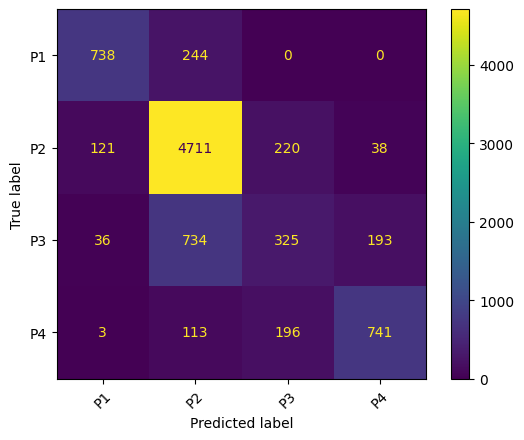

In [28]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prediction = best_pipeline.predict(x_test)

ConfusionMatrixDisplay.from_predictions(

    y_test,

    prediction,

    display_labels=label_encoder.classes_,

    xticks_rotation=45

)

plt.show()

<Figure size 1200x800 with 0 Axes>

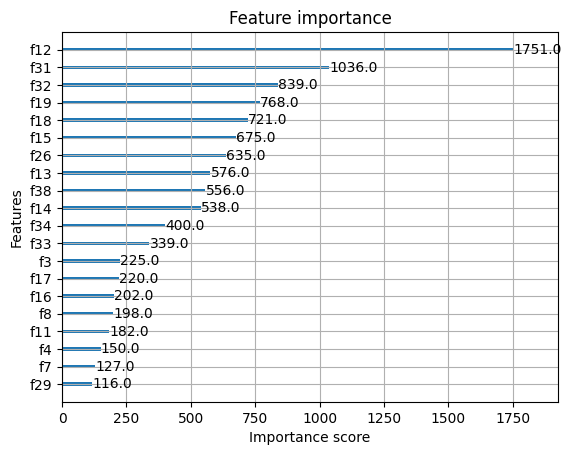

In [29]:
#Feature Importance
if best_model_name == "XGBoost":

    model = best_pipeline.named_steps["model"]

    plt.figure(figsize=(12,8))

    xgb.plot_importance(

        model,

        max_num_features=20

    )

    plt.show()

In [30]:
#Save the Best Pipeline
joblib.dump(

    best_pipeline,

    "credit_approval_pipeline.pkl"

)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [31]:
#Save Label Encoder
joblib.dump(

    label_encoder,

    "label_encoder.pkl"

)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


In [32]:
#Save Model Comparision
comparison.to_csv(

    "Model_Comparison.csv",

    index=False

)

comparison

,Model,Accuracy,Macro F1
2,XGBoost,0.774397,0.675588
1,Random Forest,0.767978,0.656591
0,Decision Tree,0.747058,0.642393


In [33]:
from google.colab import files

uploaded = files.upload()

Saving New_Unseen.xlsx to New_Unseen.xlsx


In [34]:
#Load Pipeline
pipeline = joblib.load(

    "credit_approval_pipeline.pkl"

)

label_encoder = joblib.load(

    "label_encoder.pkl"

)

In [36]:
df_unseen = pd.read_excel(
    "New_Unseen.xlsx"
)

print(df_unseen.shape)

(100, 47)


In [38]:
# Keep only training features
# ==========================================================

X_unseen = df_unseen[features]

In [39]:
#Predict
prediction = pipeline.predict(

    X_unseen

)

In [40]:
#Convert Back To Labels
prediction = label_encoder.inverse_transform(

    prediction

)

In [41]:
#Add Prediction Column
df_unseen["Approved_Flag"] = prediction

In [42]:
#Prediction Summary
print(

    df_unseen["Approved_Flag"].value_counts()

)

Approved_Flag
P4    61
P3    34
P2     5
Name: count, dtype: int64


In [43]:
#Save Prediction File
df_unseen.to_excel(

    "Final_Predictions.xlsx",

    index=False

)

print("Prediction File Saved")

Prediction File Saved


In [44]:
#Download Files
from google.colab import files

files.download(

    "credit_approval_pipeline.pkl"

)

files.download(

    "label_encoder.pkl"

)

files.download(

    "Final_Predictions.xlsx"

)

files.download(

    "Model_Comparison.csv"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
print(X.columns.tolist())

['Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_closed_L6M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq', 'CC_enq_L6m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_opened_TLs_L6m_of_L12m', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


In [46]:
print(pipeline)

Pipeline(steps=[('education', EducationOrdinalEncoder()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Total_TL_opened_L6M',
                                                   'Tot_TL_closed_L6M',
                                                   'pct_tl_closed_L6M',
                                                   'pct_tl_open_L12M',
                                                   'pct_tl_closed_L12M',
                                                   'Tot_Missed_Pmnt', 'CC_TL',
                                                   'Consumer_TL', 'Gold_TL',
                                                   'Home_TL', 'PL_TL',
                                                   'Other_TL', 'Age_Oldest_TL',
                                                   'Age_Newest_TL',
                                                   'time_si...
                               fea

In [47]:
import joblib

pipeline = joblib.load("credit_approval_pipeline.pkl")
print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [48]:
import joblib

joblib.dump(best_pipeline, "credit_approval_pipeline.pkl", compress=0)
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [49]:
from google.colab import files

files.download("credit_approval_pipeline.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
import joblib

# Save education encoder
joblib.dump(
    best_pipeline.named_steps["education"],
    "education_encoder.pkl"
)

# Save preprocessor
joblib.dump(
    best_pipeline.named_steps["preprocessor"],
    "preprocessor.pkl"
)

# Save XGBoost model
best_pipeline.named_steps["model"].save_model(
    "xgb_model.json"
)

# Save label encoder
joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("All files saved successfully!")

All files saved successfully!


In [51]:
from google.colab import files

files.download("education_encoder.pkl")
files.download("preprocessor.pkl")
files.download("xgb_model.json")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
import os

print(os.listdir())

['.config', 'New_Unseen.xlsx', 'preprocessor.pkl', 'Model_Comparison.csv', 'Final_Predictions.xlsx', 'case_study2.xlsx', 'credit_approval_pipeline.pkl', 'label_encoder.pkl', 'xgb_model.json', 'case_study1.xlsx', 'education_encoder.pkl', 'sample_data']
